In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import optuna
import math
import time
from tqdm import tqdm
from pprint import pprint

optuna.logging.set_verbosity(optuna.logging.ERROR)

ModuleNotFoundError: No module named 'pandas_ta'

In [ ]:
def load_json_candles(fname):
    data = pd.read_json(fname)
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

def load_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/{base}_{quote}-{timeframe}.json'
    return load_json_candles(fname)

def load_futures_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/futures/{base}_{quote}_{quote}-{timeframe}-futures.json'
    return load_json_candles(fname)

In [2]:
np.random.random()

0.4093964967574443

### Download various futures and other from yfinance and elsewhere

In [6]:
symbols = {
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Crude Oil': 'CL=F',
    'Natural Gas': 'NG=F',
    'Corn': 'ZC=F',
    'Soybeans': 'ZS=F'    
}



In [10]:
import yfinance as yf
import pandas as pd



data_dir = './data'
# Example: Download historical data for Gold Futures
symbol = 'GC=F'  # Gold Futures symbol on Yahoo Finance
for k,v in symbols.items():
    print(f'Downloading {k}:{v}')
    data = yf.download(v, start="2000-01-01")

    # # Display the first few rows of the data
    # print(data.head())

    # # Save to a CSV file
    data.to_csv(f'{data_dir}/{k}.csv')

[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [4]:
Data Driven Science and Engineering - Machine Learning, Dynamical Systems, and Control-Steve Burton

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,274.799988,278.299988,274.799988,278.299988,278.299988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...,...
2024-08-27,2515.199951,2523.100098,2506.899902,2516.000000,2516.000000,100
2024-08-28,2501.000000,2501.000000,2501.000000,2501.000000,2501.000000,2353
2024-08-29,2504.100098,2525.699951,2503.899902,2525.699951,2525.699951,3966


## Plot percent returns vs log returns for a range of values

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of values
values = np.linspace(0, 100, 1000)

# Calculate log returns
log_returns = np.log(values + 1)  # Adding 1 to avoid log(0)

# Calculate percent returns
percent_returns = np.exp(log_returns) - 1


# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot percent returns vs values
ax1.plot(values, log_returns, label='Log Returns')
ax1.plot(values, percent_returns, label='Percent Returns')
ax1.set_yscale('log')
ax1.set_xlabel('Values')
ax1.set_ylabel('Returns')
ax1.set_title('Log Returns and Percent Returns vs Values')
ax1.legend()
ax1.grid(True)

# Plot percent returns vs log returns
ax2.plot(log_returns, percent_returns, label='Percent Returns vs Log Returns', color='orange')
ax2.set_yscale('log')
ax2.set_xlabel('Log Returns')
ax2.set_ylabel('Percent Returns')
ax2.set_title('Percent Returns vs Log Returns')
ax2.legend()
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

## Vectorized Backtesting

In [ ]:
bull =      [0,0,0,1,1,1,1,0,0,0,0,0,1,1,1,0,0,1,1,1]
bull_exit = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

bear =      [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
bear_exit = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
close = np.random.uniform(2000, 3000, len(bull)).astype(int)

In [ ]:

short_long = [1,-1]

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.001  # 0.1% slippage per trade

data = pd.DataFrame({'close': close , 'bull': bull, 'bull_exit': bull_exit, 'bear':bear, 'bear_exit':bear_exit})

lclose = data['close'].apply(np.log)
data['position'] = ((1 in short_long) * (data['bull'] &~ data['bull_exit'])) - ((-1 in short_long) * (data['bear'] &~ data['bear_exit']))
positions_shifted = data['position'].shift().fillna(0).astype(int)
# data['positions_shifted'] = positions_shifted
data['trade'] = data['position'].diff().fillna(0).astype(int)
data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
data['strategy_returns'] = positions_shifted * (lclose.diff().fillna(0))
# trade_abs = data['trade_abs'] = data['trade'].abs()
number_of_trades = data['trade'].abs().sum()
data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
# data['cum_trade_returns'] = (-lclose * data['trade'] - (data['trade'].abs() * (transaction_cost + slippage))).cumsum() *(data['trade'] != 0)

data['entry_point'] = ((data['position'] != 0) & (data['position'] == np.sign(data['trade']))).astype(int)
data['exit_point'] = ((positions_shifted != 0) & (positions_shifted == np.sign(-data['trade']))).astype(int)

data['cumulative_returns'] = data['strategy_returns'].cumsum()
data['cum_trade_returns'] = data['cumulative_returns'] * data['exit_point']
# data.loc[(data['trade'] == 0), 'cum_trade_returns'] = 0
data['cum_trade_returns'].replace(0, pd.NA, inplace=True)
data['cum_trade_returns'] = data['cum_trade_returns'].fillna(method='ffill').fillna(0)#.diff().fillna(0)
# data['trade_returns']  = data['strategy_returns'] * (positions_shifted == -np.sign(data['trade']))
# data['cum_trade_returns'] = data['trade_returns'].cumsum()

data

## Vectorized Backtesting with Stoploss/Proffit-take as per Dr. Starke

In [48]:

from copy import copy
from datetime import datetime

def load_sp500_stock_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/sp500_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

# adj = load_sp500_stock_candles('AAPL')['adj close']
# adj.head(5)

import yfinance as yf
stk = yf.download('SPY,AAPL')
adj = stk['Adj Close']
adj

[*********************100%%**********************]  2 of 2 completed


Ticker,AAPL,SPY
Date,,
1980-12-12,0.099058,NaN
1980-12-15,0.093890,NaN
1980-12-16,0.086999,NaN
1980-12-17,0.089152,NaN
1980-12-18,0.091737,NaN
...,...,...
2024-08-02,219.860001,532.900024
2024-08-05,209.270004,517.380005
2024-08-06,207.229996,522.150024


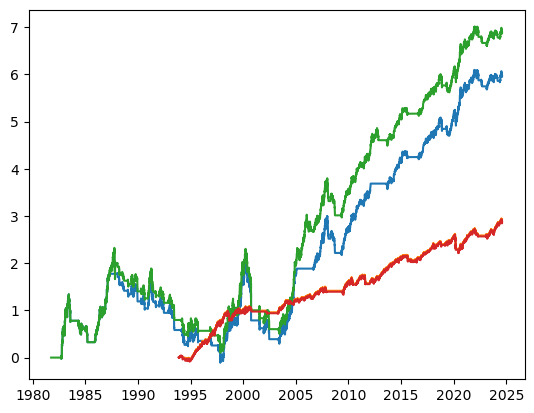

In [62]:
### LONG ONLY

# close = adj
# lclose = adj.apply(np.log)
# lrets = lclose.diff();lrets.iloc[0] = 0

sg = ((np.sign(adj.rolling(20).mean() - adj.rolling(200).mean())+1)/2)
rets = adj.pct_change()

strat_rets = rets.shift(-1) * sg
pnl = strat_rets.cumsum()
# pnl.plot(figsize=(12,3))
reset = np.sign(sg.diff())
entries = (pnl*reset.where(reset==1)).ffill()
trade_pnls = (pnl - entries)*sg
# trade_pnls.AAPL.plot()
# trade_pnls[trade_pnls > 0.5].AAPL.plot()
chopped_pnls = copy(trade_pnls)
a = sg.diff()
# a.plot()
b=(-(np.sign(chopped_pnls[chopped_pnls > 1.5]).fillna(0).diff().replace(0,np.nan)+1)/2).fillna(0)
new_sg = (((a+b).replace(0,np.nan).ffill()+1)/2)
# sg.AAPL.plot()
# new_sg.AAPL.plot(figsize=(10,7))
# (new_sg*rets.shift(-1)).cumsum().plot()
new_strat_rets = (new_sg*rets.shift(-1)).cumsum()
plt.plot(new_strat_rets)
plt.plot((sg*rets.shift(-1)).cumsum())


<Axes: xlabel='Date'>

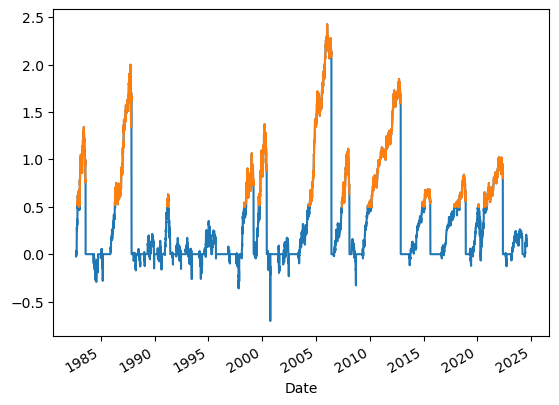

## Mean Reverting Strategy Vectorized Back Testing

In [ ]:
data = load_candles('binance', 'ETH', 'USDT', '1h')
data['lclose'] = data.close.apply(np.log)
data['lret'] = data['lclose'].diff().fillna(0)
data

In [ ]:
params= {'sma': 37, 'threshold': 0.29144194794332376}
sma, threshold = params['sma'], params['threshold']
data['sma'] = data['close'].ewm(sma).mean()
# data['sma'] = data['close'].rolling(sma).mean()
data['lsma'] = data['sma'].apply(np.log)
data['distance'] = data['lclose'] - data['lsma']

data['position'] = np.where(data['distance'] > threshold, # sell signals
                            -1, np.nan)
data['position'] = np.where(data['distance'] < -threshold, # buy signals
                            1, data['position'])
data['position'] = np.where(data['distance'] * # crossing of current price and SMA (zero distance)
                            data['distance'].shift(1) < 0,
                            0, data['position'])
data['position'] = data['position'].ffill().fillna(0)
data['returns'] = data['position'].shift(1) * data['lret']
# determine when a trade takes place
trades = data['position'].diff().fillna(0) != 0
# subtract transaction costs from return when trade takes place
# data['strategy'][trades] -= tc
data['cum_returns'] = data['returns'].cumsum()

def plotit(data):
    ax = data['lclose'].plot(figsize=(15,4))
    data['lsma'].plot(ax=ax)
    data['lsma'].subtract(threshold).plot(ax=ax)
    data['lsma'].add(threshold).plot(ax=ax)
    # data['sma'].multiply(np.exp(threshold)).plot(ax=ax)
    # data['sma'].divide(np.exp(threshold)).plot(ax=ax)
    # data['lsma'].add(threshold).apply(np.exp).plot(ax=ax)
    data['cum_returns'].apply(np.exp).subtract(1).plot(ax=ax,secondary_y=True,alpha=0.3)

plotit(data['2022':'2022'])

In [ ]:
tc = 0.001
# SMA, threshold = 15, 1.5
def run_strategy(data, params):
    sma, threshold = params['sma'], params['threshold']
    # data['sma'] = data['close'].ewm(span=sma, adjust=False).mean()
    # data['sma'] = data['close'].rolling(sma).mean()
    # data['lsma'] = data['sma'].apply(np.log)
    data['lsma'] = data['lclose'].ewm(span=sma).mean()
    data['distance'] = data['lclose'] - data['lsma']
    # data['distance'] = data['close'] - data['sma']
    data.dropna(inplace=True)
    data['position'] = np.where(data['distance'] > threshold, # sell signals
                                -1, np.nan)
    data['position'] = np.where(data['distance'] < -threshold, # buy signals
                                1, data['position'])
    data['position'] = np.where(data['distance'] * # crossing of current price and SMA (zero distance)
                                data['distance'].shift(1) < 0,
                                0, data['position'])
    data['position'] = data['position'].ffill().fillna(0)
    data['returns'] = data['position'].shift(1) * data['lret']
    # determine when a trade takes place
    data['trades'] = data['position'].diff().fillna(0) != 0
    # subtract transaction costs from return when trade takes place
    # data['strategy'][trades] -= tc
    data['cum_returns'] = data['returns'].cumsum()
    total_return = data['cum_returns'].values[-1]
    volatility = data['cum_returns'].std() + 1e4
    sharpe_ratio = total_return / volatility
    
    return {'total_return': total_return, 'volatility': volatility, 'sharpe_ratio': sharpe_ratio}


def optimize(data, short_long=None):
    def objective(trial):
        global data
        sma = trial.suggest_int('sma', 4, 50)
        threshold = trial.suggest_uniform('threshold', 0.1, 5)
        params = {'sma':sma, 'threshold':threshold}
        results = run_strategy(data, params)
        
        return results['sharpe_ratio']

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)
    return study

data = load_candles('binance', 'AVAX', 'USDT', '4h')['2023':]
data['lclose'] = data.close.apply(np.log)
data['lret'] = data['lclose'].diff().fillna(0)
# data

study = optimize(data, short_long=short_long)
params = study.best_params
# best_params= {'sma': 30, 'threshold': 0.14977762768415867}
print(f'params= {params}')
results = run_strategy(data, params)
print(f'results: {results}')

def plotit(data,params):    
    sma, threshold = params['sma'], params['threshold']
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(17, 7), sharex=True, height_ratios=[3,1])
    data['lclose'].plot(ax=ax1)
    data['lsma'].plot(ax=ax1)
    data['lsma'].subtract(threshold).plot(ax=ax1)
    data['lsma'].add(threshold).plot(ax=ax1)
    data['position'].plot(ax=ax1,secondary_y=True, alpha=0.2)
    # data['sma'].multiply(np.exp(threshold)).plot(ax=ax)
    # data['sma'].divide(np.exp(threshold)).plot(ax=ax)
    # data['lsma'].add(threshold).apply(np.exp).plot(ax=ax)
    data['cum_returns'].apply(np.exp).subtract(1).plot(ax=ax2,secondary_y=True,alpha=0.3)
    # for x in data[data['trades'].abs() !=0].index : ax1.axvline(x)

# plotit(data,params)

In [ ]:
np.get_include()